# Мультимодальное распознавание эмоций (MER)

Пайплайн: **Аудио => log-mel + CNN (VAD) => если не нейтральная => Видео => классификация эмоции**

Три подхода на видео-части (датасет **RAVDESS**, full-AV видео):
1. **Single-frame Face CNN** — один кадр => детекция лица => MobileNetV2 => классификатор
2. **Temporal Pooling (multi-frame CNN)** — 8 кадров => MobileNetV2 => mean pooling => классификатор
3. **Audio-Visual Fusion** — аудио (log-mel CNN) + видео (MobileNetV2) => конкатенация => классификатор

Метрики: **Качество** (Accuracy, F1 macro, Precision, Recall) · **Скорость** инференса · **Размер** модели

In [13]:
import os, io, time, gc, warnings
warnings.filterwarnings("ignore")

import cv2
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

SR = 16_000
N_MELS, MAX_LEN, HOP = 64, 128, 512
IMG_SIZE = 224
N_FRAMES = 8
results = []

EMOTION_MAP = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised",
}
N_CLASSES = len(EMOTION_MAP)


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2

Device: mps


## 1. Загрузка видео-данных RAVDESS

In [14]:
RAVDESS_PATH = "../datasets/ravdess/"

video_paths, emo_labels, actor_ids = [], [], []

for d in sorted(os.listdir(RAVDESS_PATH)):
    if not d.startswith("Video_Speech_Actor_"):
        continue
    actor_dir = os.path.join(RAVDESS_PATH, d)
    for actor_sub in sorted(os.listdir(actor_dir)):
        if not actor_sub.startswith("Actor_"):
            continue
        actor_path = os.path.join(actor_dir, actor_sub)
        for f in sorted(os.listdir(actor_path)):
            if not f.endswith(".mp4"):
                continue
            parts = f.replace(".mp4", "").split("-")
            modality = int(parts[0])
            if modality != 1:
                continue
            emotion = int(parts[2])
            actor = int(parts[6])
            video_paths.append(os.path.join(actor_path, f))
            emo_labels.append(emotion - 1)
            actor_ids.append(actor)

emo_labels = np.array(emo_labels)
actor_ids = np.array(actor_ids)

unique_actors = sorted(set(actor_ids))
n_test_actors = max(1, len(unique_actors) // 5)
test_actors = set(unique_actors[-n_test_actors:])

train_idx = [i for i, a in enumerate(actor_ids) if a not in test_actors]
test_idx  = [i for i, a in enumerate(actor_ids) if a in test_actors]

train_videos = [video_paths[i] for i in train_idx]
test_videos  = [video_paths[i] for i in test_idx]
y_train = emo_labels[train_idx]
y_test  = emo_labels[test_idx]

print(f"Всего видео (full-AV speech): {len(video_paths)}")
for emo_id, name in EMOTION_MAP.items():
    print(f"  {name}: {(emo_labels == emo_id - 1).sum()}")
print(f"\nSpeaker-independent split (20 % актёров => test):")
print(f"  Train: {len(train_videos)} видео ({len(unique_actors) - n_test_actors} актёров)")
print(f"  Test:  {len(test_videos)} видео ({n_test_actors} актёров)")

Всего видео (full-AV speech): 1440
  neutral: 96
  calm: 192
  happy: 192
  sad: 192
  angry: 192
  fearful: 192
  disgust: 192
  surprised: 192

Speaker-independent split (20 % актёров => test):
  Train: 1200 видео (20 актёров)
  Test:  240 видео (4 актёров)


## 2. Детекция лиц и извлечение визуальных признаков (MobileNetV2)

In [15]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

imagenet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_frames(video_path, n_frames=8):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def detect_and_crop_face(frame, target_size=IMG_SIZE):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(48, 48))
    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        pad = int(0.2 * max(w, h))
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(frame.shape[1], x + w + pad)
        y2 = min(frame.shape[0], y + h + pad)
        face = frame[y1:y2, x1:x2]
    else:
        h, w = frame.shape[:2]
        s = min(h, w)
        y1, x1 = (h - s) // 2, (w - s) // 2
        face = frame[y1:y1 + s, x1:x1 + s]
    return cv2.resize(face, (target_size, target_size))


print("Утилиты загружены ✓")

Утилиты загружены ✓


In [16]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet.classifier = nn.Identity()
mobilenet = mobilenet.to(device).eval()
FEAT_DIM = 1280

mobilenet_mb = pytorch_size_mb(mobilenet)
print(f"MobileNetV2 feature extractor: {mobilenet_mb:.1f} MB, output dim={FEAT_DIM}")


def extract_vis_features(video_list, n_frames=N_FRAMES):
    all_feats = []
    for vp in tqdm(video_list):
        frames = extract_frames(vp, n_frames)
        if not frames:
            all_feats.append(torch.zeros(n_frames, FEAT_DIM))
            continue
        while len(frames) < n_frames:
            frames.append(frames[-1])
        faces = torch.stack(
            [imagenet_transform(detect_and_crop_face(f)) for f in frames[:n_frames]]
        )
        with torch.no_grad():
            feats = mobilenet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


print("Извлечение визуальных признаков (MobileNetV2)...")
train_vis = extract_vis_features(train_videos)
test_vis  = extract_vis_features(test_videos)
print(f"Train visual: {train_vis.shape}  |  Test visual: {test_vis.shape}")

MobileNetV2 feature extractor: 8.6 MB, output dim=1280
Извлечение визуальных признаков (MobileNetV2)...


100%|██████████| 240/240 [00:52<00:00,  4.61it/s]

Train visual: torch.Size([1200, 8, 1280])  |  Test visual: torch.Size([240, 8, 1280])


## 3. Подход 1: Single-frame Face CNN

Один ключевой кадр (средний) => детекция лица => MobileNetV2 признаки => FC-классификатор

In [17]:
class FCClassifier(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        return self.net(x)


mid = N_FRAMES // 2
X_train_1 = train_vis[:, mid, :]
X_test_1  = test_vis[:, mid, :]

model_1 = FCClassifier(FEAT_DIM, N_CLASSES).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

ds1 = TensorDataset(X_train_1, torch.tensor(y_train, dtype=torch.long))
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_1(xb), yb)
        opt1.zero_grad(); loss.backward(); opt1.step()
    if (ep + 1) % 10 == 0:
        model_1.eval()
        with torch.no_grad():
            acc = (model_1(X_train_1.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_1 = time.time() - t0

# End-to-end инференс (от видео до предсказания)
model_1.eval()
t0 = time.time()
preds_1 = []
for vp in test_videos:
    frames = extract_frames(vp, 1)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)]
    face = detect_and_crop_face(frames[0])
    face_t = imagenet_transform(face).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = mobilenet(face_t)
        preds_1.append(model_1(feat).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_videos)
preds_1 = np.array(preds_1)

cls_1_mb = pytorch_size_mb(model_1)
pipe_1_mb = mobilenet_mb + cls_1_mb

results.append({
    "Модель": "Single-frame CNN",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": pipe_1_mb,
})
print(f"\nSingle-frame CNN => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={pipe_1_mb:.1f} MB")

Epoch 10/50 | Loss 1.3093 | Train Acc 0.6633
Epoch 20/50 | Loss 0.8815 | Train Acc 0.7508
Epoch 30/50 | Loss 0.9114 | Train Acc 0.8142
Epoch 40/50 | Loss 0.5502 | Train Acc 0.8542
Epoch 50/50 | Loss 0.6315 | Train Acc 0.9058

Single-frame CNN => Acc=0.1083 F1=0.0826 Inf=51.5 мс/файл  Pipeline=9.2 MB


## 4. Подход 2: Temporal Pooling (multi-frame CNN)

8 кадров => детекция лиц => MobileNetV2 признаки => mean pooling => FC-классификатор

In [18]:
X_train_2 = train_vis.mean(dim=1)
X_test_2  = test_vis.mean(dim=1)

model_2 = FCClassifier(FEAT_DIM, N_CLASSES).to(device)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)

ds2 = TensorDataset(X_train_2, torch.tensor(y_train, dtype=torch.long))
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_2(xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 10 == 0:
        model_2.eval()
        with torch.no_grad():
            acc = (model_2(X_train_2.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        feats = mobilenet(faces.to(device))
        pooled = feats.mean(dim=0, keepdim=True)
        preds_2.append(model_2(pooled).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_videos)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
pipe_2_mb = mobilenet_mb + cls_2_mb

results.append({
    "Модель": "Temporal Pooling",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": pipe_2_mb,
})
print(f"\nTemporal Pooling => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Pipeline={pipe_2_mb:.1f} MB")

Epoch 10/50 | Loss 1.2733 | Train Acc 0.6308
Epoch 20/50 | Loss 0.4557 | Train Acc 0.7875
Epoch 30/50 | Loss 0.7717 | Train Acc 0.8633
Epoch 40/50 | Loss 0.7504 | Train Acc 0.8650
Epoch 50/50 | Loss 0.5364 | Train Acc 0.9167

Temporal Pooling => Acc=0.3917 F1=0.3661 Inf=223.4 мс/файл  Pipeline=9.2 MB


## 5. Подход 3: Audio-Visual Fusion

### 5.1 Извлечение аудио-признаков (log-mel спектрограмма)

In [19]:
def extract_log_mel(path):
    y, _ = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    return lm


print("Извлечение log-mel спектрограмм из аудиодорожек видео...")
X_mel_train = np.array([extract_log_mel(f) for f in tqdm(train_videos)])
X_mel_test  = np.array([extract_log_mel(f) for f in tqdm(test_videos)])

mel_mean, mel_std = X_mel_train.mean(), X_mel_train.std()
X_mel_train = (X_mel_train - mel_mean) / (mel_std + 1e-8)
X_mel_test  = (X_mel_test  - mel_mean) / (mel_std + 1e-8)
print(f"Log-mel: train={X_mel_train.shape}, test={X_mel_test.shape}")

Извлечение log-mel спектрограмм из аудиодорожек видео...


100%|██████████| 240/240 [00:02<00:00, 98.15it/s] 

Log-mel: train=(1200, 64, 128), test=(240, 64, 128)


### 5.2 Audio-Visual Fusion модель

Визуальная ветвь: MobileNetV2 (frozen) => mean-pooled features (1280-d)
Аудиоветвь: log-mel => 3×Conv2d => embedding (64-d)
Слияние: конкатенация => FC => классификация

In [20]:
AUDIO_FEAT_DIM = 64


class AudioBranch(nn.Module):
    def __init__(self, n_mels=64, max_len=128, feat_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), feat_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.embed(self.conv(x))


class AudioVisualFusion(nn.Module):
    def __init__(self, vis_dim=1280, audio_feat_dim=64, n_classes=8):
        super().__init__()
        self.audio_branch = AudioBranch(feat_dim=audio_feat_dim)
        self.head = nn.Sequential(
            nn.Linear(vis_dim + audio_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, vis_feat, mel_spec):
        audio_feat = self.audio_branch(mel_spec)
        fused = torch.cat([vis_feat, audio_feat], dim=1)
        return self.head(fused)


model_3 = AudioVisualFusion(FEAT_DIM, AUDIO_FEAT_DIM, N_CLASSES).to(device)
opt3 = optim.Adam(model_3.parameters(), lr=1e-3, weight_decay=1e-4)

vis_train = train_vis.mean(dim=1)
vis_test  = test_vis.mean(dim=1)
mel_train_t = torch.tensor(X_mel_train[:, None], dtype=torch.float32)
mel_test_t  = torch.tensor(X_mel_test[:, None], dtype=torch.float32)

ds3 = TensorDataset(
    vis_train, mel_train_t, torch.tensor(y_train, dtype=torch.long),
)
loader3 = DataLoader(ds3, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_3.train()
    for vb, ab, yb in loader3:
        vb, ab, yb = vb.to(device), ab.to(device), yb.to(device)
        loss = crit(model_3(vb, ab), yb)
        opt3.zero_grad(); loss.backward(); opt3.step()
    if (ep + 1) % 10 == 0:
        model_3.eval()
        with torch.no_grad():
            preds = model_3(
                vis_train.to(device), mel_train_t.to(device),
            ).argmax(1).cpu().numpy()
            acc = (preds == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_3 = time.time() - t0

# End-to-end инференс
model_3.eval()
t0 = time.time()
preds_3 = []
for vp in test_videos:
    # Visual
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        vis_feat = mobilenet(faces.to(device)).mean(dim=0, keepdim=True)
    # Audio
    lm = extract_log_mel(vp)
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    mel_t = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_3.append(model_3(vis_feat, mel_t).argmax(1).item())
inf_time_3 = (time.time() - t0) / len(test_videos)
preds_3 = np.array(preds_3)

cls_3_mb = pytorch_size_mb(model_3)
pipe_3_mb = mobilenet_mb + cls_3_mb

results.append({
    "Модель": "Audio-Visual Fusion",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": cls_3_mb,
    "Пайплайн (MB)": pipe_3_mb,
})
print(f"\nAudio-Visual Fusion => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Pipeline={pipe_3_mb:.1f} MB")

Epoch 10/50 | Loss 0.4501 | Train Acc 0.9050
Epoch 20/50 | Loss 0.0150 | Train Acc 0.9892
Epoch 30/50 | Loss 0.0195 | Train Acc 1.0000
Epoch 40/50 | Loss 0.0801 | Train Acc 1.0000
Epoch 50/50 | Loss 0.0117 | Train Acc 1.0000

Audio-Visual Fusion => Acc=0.5167 F1=0.4994 Inf=221.3 мс/файл  Pipeline=11.4 MB


## 7.0 Сводная таблица и визуализация

In [21]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(index=False, formatters={k: v.format for k, v in fmt.items()}))

emo_names = [EMOTION_MAP[i + 1] for i in range(N_CLASSES)]

for name, preds in [
    ("Single-frame CNN", preds_1),
    ("Temporal Pooling", preds_2),
    ("Audio-Visual Fusion (concat)", preds_3),
    ("Weighted Concat", preds_1),
    ("Gated Fusion", preds_2),
    ("Late Fusion", preds_3),
]:
    print(f"\n{'=' * 60}")
    print(name)
    print(classification_report(y_test, preds, target_names=emo_names, zero_division=0))

             Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
   Single-frame CNN   0.1083     0.0826    0.2450 0.1211               51.5            5.1              0.629          9.24
   Temporal Pooling   0.3917     0.3661    0.4966 0.3984              223.4            5.0              0.629          9.24
Audio-Visual Fusion   0.5167     0.4994    0.6248 0.4961              221.3           17.6              2.752         11.37

Single-frame CNN
              precision    recall  f1-score   support

     neutral       0.06      0.31      0.11        16
        calm       0.14      0.31      0.19        32
       happy       1.00      0.03      0.06        32
         sad       0.06      0.03      0.04        32
       angry       0.07      0.03      0.04        32
     fearful       0.50      0.03      0.06        32
     disgust       0.00      0.00      0.00        32
   surprised       0.12      0.22      0.16        32

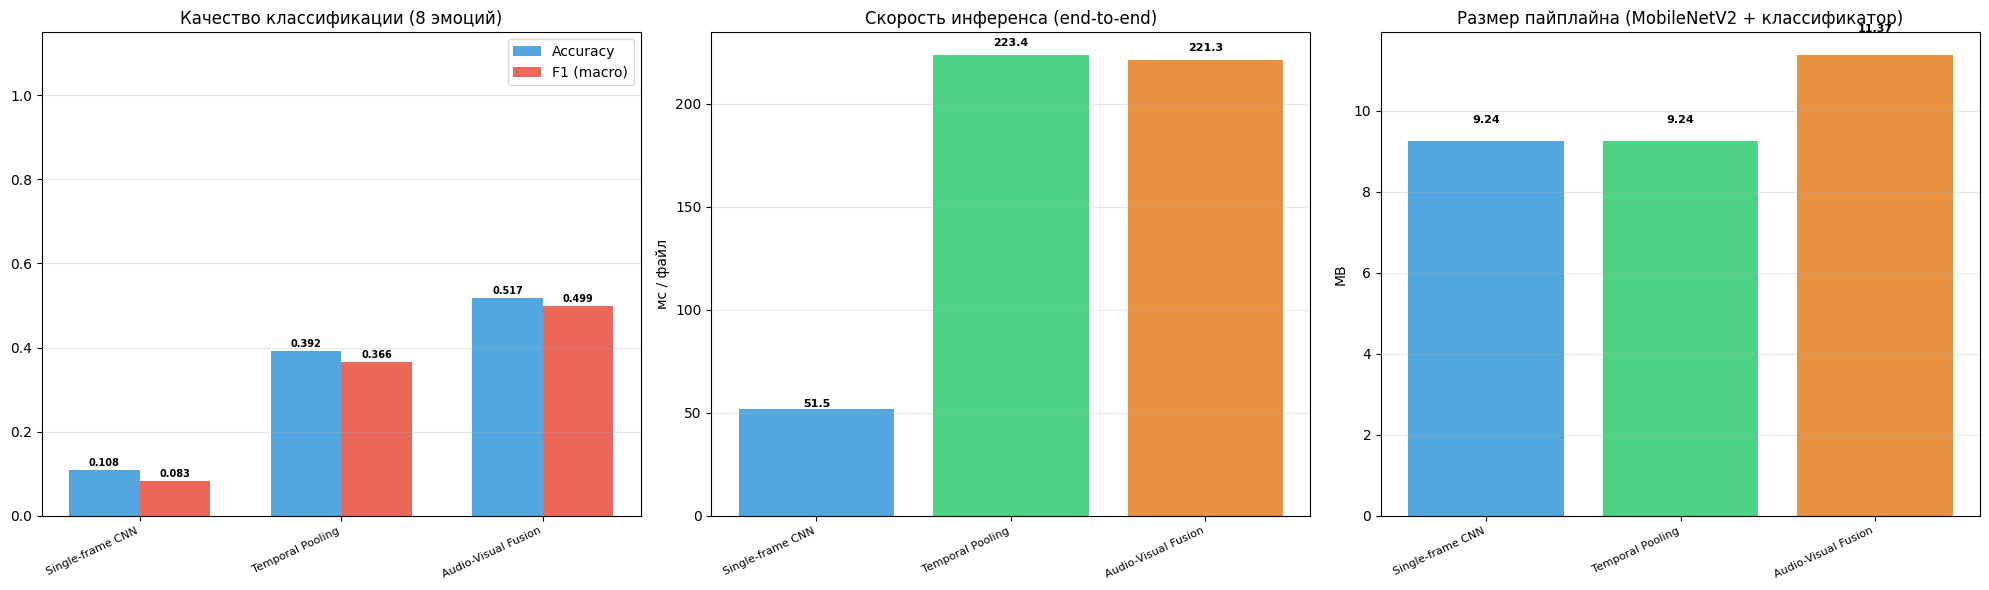

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = df["Модель"].tolist()
x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

# ── Качество ──
w = 0.35
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[0].set_title("Качество классификации (8 эмоций)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса (end-to-end)")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
                 f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна (MobileNetV2 + классификатор)")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
                 f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Дополнительные стратегии Audio-Visual Fusion

### 8.1 Weighted Concat Fusion

Обучаемые скалярные веса для каждой модальности перед конкатенацией:
`σ(w_v) · vis ‖ σ(w_a) · aud => FC => классификация`

In [23]:
class WeightedConcatFusion(nn.Module):
    def __init__(self, vis_dim=1280, audio_feat_dim=64, n_classes=8):
        super().__init__()
        self.audio_branch = AudioBranch(feat_dim=audio_feat_dim)
        self.w_vis = nn.Parameter(torch.ones(1))
        self.w_aud = nn.Parameter(torch.ones(1))
        self.head = nn.Sequential(
            nn.Linear(vis_dim + audio_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, vis_feat, mel_spec):
        audio_feat = self.audio_branch(mel_spec)
        fused = torch.cat([
            torch.sigmoid(self.w_vis) * vis_feat,
            torch.sigmoid(self.w_aud) * audio_feat,
        ], dim=1)
        return self.head(fused)


model_wc = WeightedConcatFusion(FEAT_DIM, AUDIO_FEAT_DIM, N_CLASSES).to(device)
opt_wc = optim.Adam(model_wc.parameters(), lr=1e-3, weight_decay=1e-4)

ds_wc = TensorDataset(vis_train, mel_train_t, torch.tensor(y_train, dtype=torch.long))
loader_wc = DataLoader(ds_wc, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_wc.train()
    for vb, ab, yb in loader_wc:
        vb, ab, yb = vb.to(device), ab.to(device), yb.to(device)
        loss = crit(model_wc(vb, ab), yb)
        opt_wc.zero_grad(); loss.backward(); opt_wc.step()
    if (ep + 1) % 10 == 0:
        model_wc.eval()
        with torch.no_grad():
            acc = (model_wc(vis_train.to(device), mel_train_t.to(device))
                   .argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_wc = time.time() - t0

with torch.no_grad():
    print(f"Learned weights: visual={torch.sigmoid(model_wc.w_vis).item():.3f}, "
          f"audio={torch.sigmoid(model_wc.w_aud).item():.3f}")

model_wc.eval()
t0 = time.time()
preds_wc = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        vis_f = mobilenet(faces.to(device)).mean(dim=0, keepdim=True)
    lm = extract_log_mel(vp)
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    mel_t = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_wc.append(model_wc(vis_f, mel_t).argmax(1).item())
inf_time_wc = (time.time() - t0) / len(test_videos)
preds_wc = np.array(preds_wc)

cls_wc_mb = pytorch_size_mb(model_wc)
pipe_wc_mb = mobilenet_mb + cls_wc_mb

results.append({
    "Модель": "Weighted Concat",
    "Accuracy": accuracy_score(y_test, preds_wc),
    "F1 (macro)": f1_score(y_test, preds_wc, average="macro"),
    "Precision": precision_score(y_test, preds_wc, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_wc, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_wc * 1000,
    "Обучение (сек)": train_time_wc,
    "Классификатор (MB)": cls_wc_mb,
    "Пайплайн (MB)": pipe_wc_mb,
})
print(f"\nWeighted Concat => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_wc*1000:.1f} мс/файл  Pipeline={pipe_wc_mb:.1f} MB")

Epoch 10/50 | Loss 0.4621 | Train Acc 0.8592
Epoch 20/50 | Loss 0.0482 | Train Acc 0.9825
Epoch 30/50 | Loss 0.1498 | Train Acc 0.9967
Epoch 40/50 | Loss 0.0053 | Train Acc 1.0000
Epoch 50/50 | Loss 0.0839 | Train Acc 1.0000
Learned weights: visual=0.826, audio=0.816

Weighted Concat => Acc=0.5667 F1=0.5569 Inf=230.5 мс/файл  Pipeline=11.4 MB


### 8.2 Gated Fusion

Обе модальности проецируются в общее пространство, затем обучаемый гейт
динамически взвешивает вклад каждой: `g · v + (1−g) · a => FC`

In [24]:
class GatedFusion(nn.Module):
    def __init__(self, vis_dim=1280, audio_feat_dim=64, proj_dim=128, n_classes=8):
        super().__init__()
        self.audio_branch = AudioBranch(feat_dim=audio_feat_dim)
        self.vis_proj = nn.Linear(vis_dim, proj_dim)
        self.aud_proj = nn.Linear(audio_feat_dim, proj_dim)
        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.Sigmoid(),
        )
        self.head = nn.Sequential(
            nn.Linear(proj_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, vis_feat, mel_spec):
        audio_feat = self.audio_branch(mel_spec)
        v = torch.relu(self.vis_proj(vis_feat))
        a = torch.relu(self.aud_proj(audio_feat))
        g = self.gate(torch.cat([v, a], dim=1))
        fused = g * v + (1 - g) * a
        return self.head(fused)


model_gf = GatedFusion(FEAT_DIM, AUDIO_FEAT_DIM, 128, N_CLASSES).to(device)
opt_gf = optim.Adam(model_gf.parameters(), lr=1e-3, weight_decay=1e-4)

ds_gf = TensorDataset(vis_train, mel_train_t, torch.tensor(y_train, dtype=torch.long))
loader_gf = DataLoader(ds_gf, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_gf.train()
    for vb, ab, yb in loader_gf:
        vb, ab, yb = vb.to(device), ab.to(device), yb.to(device)
        loss = crit(model_gf(vb, ab), yb)
        opt_gf.zero_grad(); loss.backward(); opt_gf.step()
    if (ep + 1) % 10 == 0:
        model_gf.eval()
        with torch.no_grad():
            acc = (model_gf(vis_train.to(device), mel_train_t.to(device))
                   .argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_gf = time.time() - t0

model_gf.eval()
t0 = time.time()
preds_gf = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        vis_f = mobilenet(faces.to(device)).mean(dim=0, keepdim=True)
    lm = extract_log_mel(vp)
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    mel_t = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_gf.append(model_gf(vis_f, mel_t).argmax(1).item())
inf_time_gf = (time.time() - t0) / len(test_videos)
preds_gf = np.array(preds_gf)

cls_gf_mb = pytorch_size_mb(model_gf)
pipe_gf_mb = mobilenet_mb + cls_gf_mb

results.append({
    "Модель": "Gated Fusion",
    "Accuracy": accuracy_score(y_test, preds_gf),
    "F1 (macro)": f1_score(y_test, preds_gf, average="macro"),
    "Precision": precision_score(y_test, preds_gf, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_gf, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_gf * 1000,
    "Обучение (сек)": train_time_gf,
    "Классификатор (MB)": cls_gf_mb,
    "Пайплайн (MB)": pipe_gf_mb,
})
print(f"\nGated Fusion => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_gf*1000:.1f} мс/файл  Pipeline={pipe_gf_mb:.1f} MB")

Epoch 10/50 | Loss 0.3645 | Train Acc 0.9167
Epoch 20/50 | Loss 0.2509 | Train Acc 0.9775
Epoch 30/50 | Loss 0.0063 | Train Acc 0.9933
Epoch 40/50 | Loss 0.0155 | Train Acc 0.9700
Epoch 50/50 | Loss 0.0155 | Train Acc 1.0000

Gated Fusion => Acc=0.6042 F1=0.5970 Inf=232.2 мс/файл  Pipeline=11.5 MB


### 8.3 Late Fusion (по вероятностям)

Отдельные классификаторы для видео и аудио, итоговое предсказание —
среднее softmax-вероятностей: `(P_vis + P_aud) / 2`

In [25]:
class AudioOnlyClassifier(nn.Module):
    def __init__(self, feat_dim=64, n_classes=8):
        super().__init__()
        self.audio_branch = AudioBranch(feat_dim=feat_dim)
        self.head = nn.Sequential(
            nn.Linear(feat_dim, n_classes),
        )

    def forward(self, mel):
        return self.head(self.audio_branch(mel))


# ── Визуальный классификатор ──
vis_late = FCClassifier(FEAT_DIM, N_CLASSES).to(device)
opt_vl = optim.Adam(vis_late.parameters(), lr=1e-3, weight_decay=1e-4)

ds_vl = TensorDataset(vis_train, torch.tensor(y_train, dtype=torch.long))
loader_vl = DataLoader(ds_vl, batch_size=32, shuffle=True)

t0_total = time.time()
for ep in range(50):
    vis_late.train()
    for xb, yb in loader_vl:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(vis_late(xb), yb)
        opt_vl.zero_grad(); loss.backward(); opt_vl.step()
    if (ep + 1) % 25 == 0:
        vis_late.eval()
        with torch.no_grad():
            acc = (vis_late(vis_train.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"[Visual] Epoch {ep+1}/50 | Train Acc {acc:.4f}")

# ── Аудио классификатор ──
aud_late = AudioOnlyClassifier(AUDIO_FEAT_DIM, N_CLASSES).to(device)
opt_al = optim.Adam(aud_late.parameters(), lr=1e-3, weight_decay=1e-4)

ds_al = TensorDataset(mel_train_t, torch.tensor(y_train, dtype=torch.long))
loader_al = DataLoader(ds_al, batch_size=32, shuffle=True)

for ep in range(50):
    aud_late.train()
    for xb, yb in loader_al:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(aud_late(xb), yb)
        opt_al.zero_grad(); loss.backward(); opt_al.step()
    if (ep + 1) % 25 == 0:
        aud_late.eval()
        with torch.no_grad():
            acc = (aud_late(mel_train_t.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"[Audio]  Epoch {ep+1}/50 | Train Acc {acc:.4f}")
train_time_lf = time.time() - t0_total

# ── Late Fusion инференс ──
vis_late.eval(); aud_late.eval()
t0 = time.time()
preds_lf = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        vis_f = mobilenet(faces.to(device)).mean(dim=0, keepdim=True)
        vis_probs = torch.softmax(vis_late(vis_f), dim=1)
    lm = extract_log_mel(vp)
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    mel_t = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        aud_probs = torch.softmax(aud_late(mel_t), dim=1)
    avg_probs = (vis_probs + aud_probs) / 2
    preds_lf.append(avg_probs.argmax(1).item())
inf_time_lf = (time.time() - t0) / len(test_videos)
preds_lf = np.array(preds_lf)

cls_lf_mb = pytorch_size_mb(vis_late) + pytorch_size_mb(aud_late)
pipe_lf_mb = mobilenet_mb + cls_lf_mb

results.append({
    "Модель": "Late Fusion",
    "Accuracy": accuracy_score(y_test, preds_lf),
    "F1 (macro)": f1_score(y_test, preds_lf, average="macro"),
    "Precision": precision_score(y_test, preds_lf, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_lf, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_lf * 1000,
    "Обучение (сек)": train_time_lf,
    "Классификатор (MB)": cls_lf_mb,
    "Пайплайн (MB)": pipe_lf_mb,
})
print(f"\nLate Fusion => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_lf*1000:.1f} мс/файл  Pipeline={pipe_lf_mb:.1f} MB")

[Visual] Epoch 25/50 | Train Acc 0.8367
[Visual] Epoch 50/50 | Train Acc 0.9258
[Audio]  Epoch 25/50 | Train Acc 1.0000
[Audio]  Epoch 50/50 | Train Acc 1.0000

Late Fusion => Acc=0.5500 F1=0.5357 Inf=232.9 мс/файл  Pipeline=11.3 MB


In [26]:
mobilenet.cpu()
model_1.cpu(); model_2.cpu(); model_3.cpu()
model_wc.cpu(); model_gf.cpu()
vis_late.cpu(); aud_late.cpu()
del train_vis, test_vis, X_mel_train, X_mel_test
del mel_train_t, mel_test_t, vis_train, vis_test
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()
print("Память очищена ✓")

Память очищена ✓


## 9. Сводная таблица и визуализация

In [27]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(index=False, formatters={k: v.format for k, v in fmt.items()}))

emo_names = [EMOTION_MAP[i + 1] for i in range(N_CLASSES)]

for name, preds in [
    ("Single-frame CNN", preds_1),
    ("Temporal Pooling", preds_2),
    ("Audio-Visual Fusion (concat)", preds_3),
    ("Weighted Concat", preds_wc),
    ("Gated Fusion", preds_gf),
    ("Late Fusion", preds_lf),
]:
    print(f"\n{'=' * 60}")
    print(name)
    print(classification_report(y_test, preds, target_names=emo_names, zero_division=0))

             Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
   Single-frame CNN   0.1083     0.0826    0.2450 0.1211               51.5            5.1              0.629          9.24
   Temporal Pooling   0.3917     0.3661    0.4966 0.3984              223.4            5.0              0.629          9.24
Audio-Visual Fusion   0.5167     0.4994    0.6248 0.4961              221.3           17.6              2.752         11.37
    Weighted Concat   0.5667     0.5569    0.6179 0.5625              230.5           18.9              2.752         11.37
       Gated Fusion   0.6042     0.5970    0.6232 0.6133              232.2           20.1              2.907         11.52
        Late Fusion   0.5500     0.5357    0.5955 0.5430              232.9           24.6              2.722         11.34

Single-frame CNN
              precision    recall  f1-score   support

     neutral       0.06      0.31      0.11        16
     

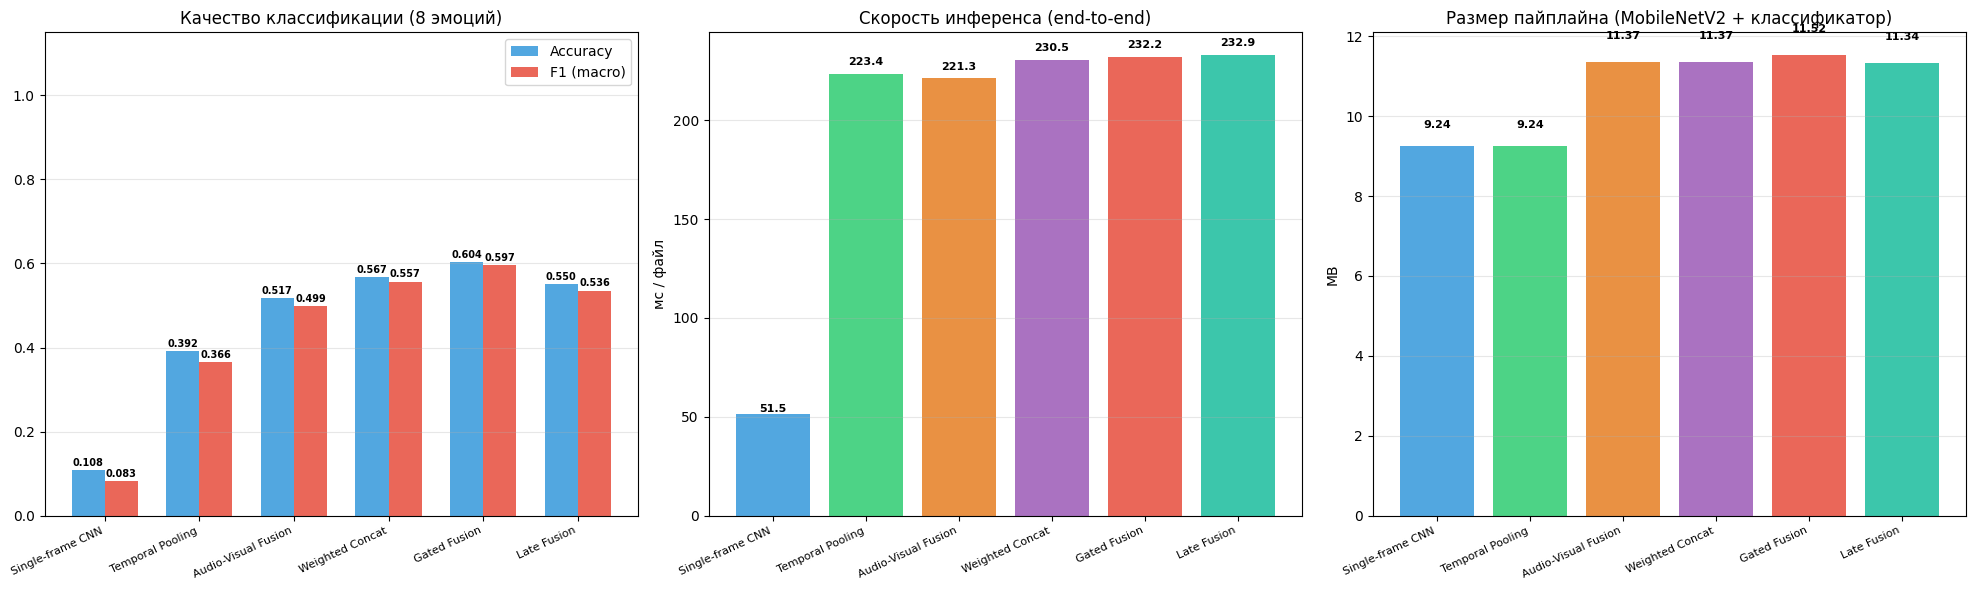

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = df["Модель"].tolist()
x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

# ── Качество ──
w = 0.35
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[0].set_title("Качество классификации (8 эмоций)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса (end-to-end)")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
                 f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна (MobileNetV2 + классификатор)")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
                 f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()